# Credit Risk Intelligence Platform
## Notebook 3 — XGBoost Modelling + Fairness Audit

**What this notebook does:**
1. Train XGBoost classifier on engineered features
2. Evaluate with ROC-AUC, PR curve, confusion matrix
3. Compare performance across borrower personas
4. Fairness audit — does the model discriminate by
   age group or home ownership?
5. Risk action scorecard — tier + recommended action



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split,
                                      StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics          import (roc_auc_score,
                                      roc_curve,
                                      precision_recall_curve,
                                      classification_report,
                                      confusion_matrix)
from sklearn.preprocessing    import StandardScaler
from xgboost                  import XGBClassifier
from sklearn.ensemble         import RandomForestClassifier

os.makedirs('./outputs', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3154',
    'grid.linewidth':   0.5,
})
ACCENT = '#7c6af7'
RED    = '#ef4444'
GREEN  = '#10b981'
YELLOW = '#f59e0b'
BLUE   = '#56b4e9'

print("Imports done")

Imports done


In [2]:
data = np.load('./data/features.npz', allow_pickle=True)
X             = data['X']
y             = data['y']
feature_names = np.load('./data/feature_names.npy',
                        allow_pickle=True).tolist()
df            = pd.read_csv('./data/df_featured.csv')

print(f"    Feature matrix: {X.shape}")
print(f"    Default rate:   {y.mean()*100:.1f}%")
print(f"    Features:       {len(feature_names)}")
print(f"    Personas:\n{df['persona'].value_counts()}")

    Feature matrix: (31677, 31)
    Default rate:   21.5%
    Features:       31
    Personas:
persona
Cautious Low-Income Borrower    20887
At-Risk Young Borrower          10790
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Keep test set indices to link back to df
_, test_idx = train_test_split(
    df.index, test_size=0.2,
    random_state=42,
    stratify=y
)
df_test = df.loc[test_idx].reset_index(drop=True)

print(f"    Split done")
print(f"    Train: {X_train.shape[0]:,}  |  defaults: {y_train.sum():,}")
print(f"    Test:  {X_test.shape[0]:,}   |  defaults: {y_test.sum():,}")

    Split done
    Train: 25,341  |  defaults: 5,460
    Test:  6,336   |  defaults: 1,365


## Class Imbalance

21% default rate is reasonably balanced compared to most
fraud datasets. We still use `scale_pos_weight` in XGBoost
to ensure the minority class (defaulters) gets enough weight.

We also compare XGBoost vs Random Forest — the model with
the higher CV AUC becomes our production model.

In [4]:
scale_w = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_w:.2f}\n")

models = {
    'XGBoost': XGBClassifier(
        n_estimators      = 500,
        max_depth         = 5,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = scale_w,
        eval_metric       = 'logloss',
        random_state      = 42,
        n_jobs            = -1,
        verbosity         = 0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators  = 300,
        max_depth     = 10,
        class_weight  = 'balanced',
        random_state  = 42,
        n_jobs        = -1
    )
}

results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True,
                          random_state=42)

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_prob   = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    cv_aucs  = cross_val_score(model, X_train, y_train,
                               cv=cv, scoring='roc_auc',
                               n_jobs=-1)

    results[name] = {
        'model':    model,
        'y_prob':   y_prob,
        'test_auc': test_auc,
        'cv_mean':  cv_aucs.mean(),
        'cv_std':   cv_aucs.std(),
    }

    print(f"    Test AUC : {test_auc:.4f}")
    print(f"      CV AUC  : {cv_aucs.mean():.4f} "
          f"± {cv_aucs.std():.4f}\n")

best_name  = max(results, key=lambda k: results[k]['test_auc'])
best_model = results[best_name]['model']
best_prob  = results[best_name]['y_prob']

print(f"  Best model: {best_name}")
print(f"  Note this AUC for your resume")

scale_pos_weight: 3.64

Training XGBoost...
    Test AUC : 0.9519
      CV AUC  : 0.9473 ± 0.0025

Training Random Forest...
    Test AUC : 0.9335
      CV AUC  : 0.9244 ± 0.0041

  Best model: XGBoost
  Note this AUC for your resume


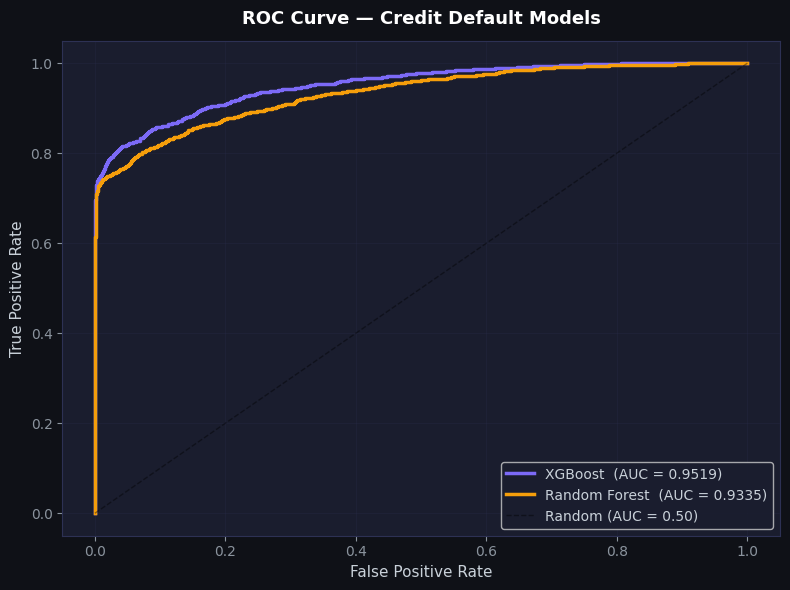

  Saved: ./outputs/roc_curves.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

colors = [ACCENT, YELLOW]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2.5, color=color,
            label=f"{name}  (AUC = {res['test_auc']:.4f})")

ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1,
        label='Random (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('ROC Curve — Credit Default Models',
             fontsize=13, fontweight='bold',
             color='white', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/roc_curves.png")

In [6]:
precision, recall, thresholds = precision_recall_curve(
    y_test, best_prob)

# F2 — recall weighted more heavily than precision
# Missing a real default is worse than a false alarm
f2 = (5 * precision * recall) / (
      4 * precision + recall + 1e-9)

best_idx   = np.argmax(f2)
opt_thresh = thresholds[best_idx]

print(f"Optimal threshold (F2): {opt_thresh:.3f}")
print(f"Precision at optimal:   {precision[best_idx]:.3f}")
print(f"Recall at optimal:      {recall[best_idx]:.3f}")

print(f"\nDefault threshold (0.50) report:")
y_pred_def = (best_prob >= 0.50).astype(int)
print(classification_report(y_test, y_pred_def,
      target_names=['No Default','Default']))

print(f"\nOptimal threshold ({opt_thresh:.3f}) report:")
y_pred_opt = (best_prob >= opt_thresh).astype(int)
print(classification_report(y_test, y_pred_opt,
      target_names=['No Default','Default']))

print("  Note the recall improvement — that's your resume bullet")

Optimal threshold (F2): 0.385
Precision at optimal:   0.729
Recall at optimal:      0.853

Default threshold (0.50) report:
              precision    recall  f1-score   support

  No Default       0.95      0.96      0.96      4971
     Default       0.86      0.81      0.83      1365

    accuracy                           0.93      6336
   macro avg       0.90      0.89      0.89      6336
weighted avg       0.93      0.93      0.93      6336


Optimal threshold (0.385) report:
              precision    recall  f1-score   support

  No Default       0.96      0.91      0.93      4971
     Default       0.73      0.85      0.79      1365

    accuracy                           0.90      6336
   macro avg       0.84      0.88      0.86      6336
weighted avg       0.91      0.90      0.90      6336

  Note the recall improvement — that's your resume bullet


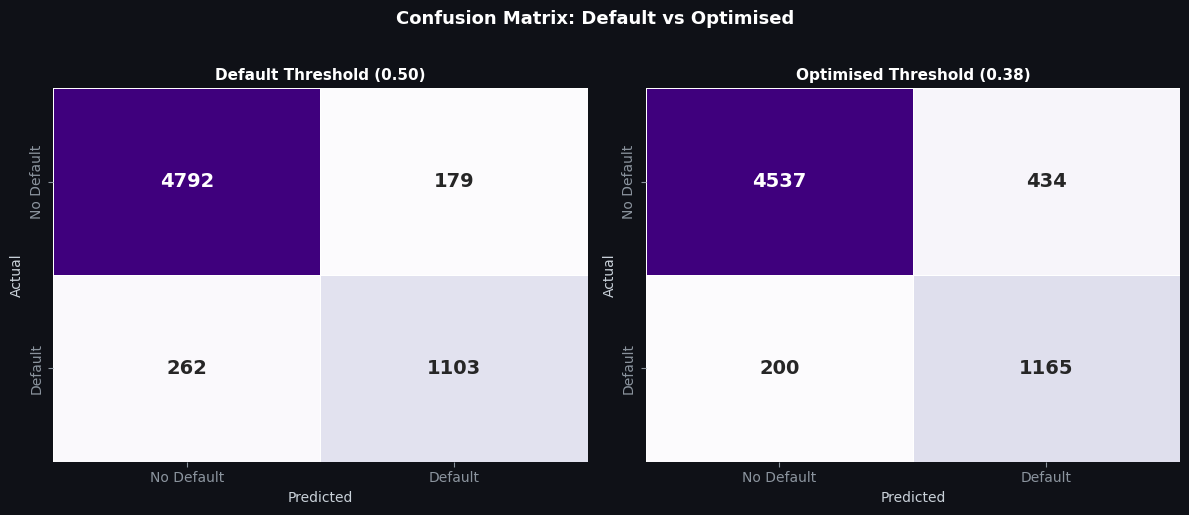

  Saved: ./outputs/confusion_matrix.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')

for ax, (thresh, label) in zip(axes, [
    (0.50,      'Default Threshold (0.50)'),
    (opt_thresh, f'Optimised Threshold ({opt_thresh:.2f})')
]):
    ax.set_facecolor('#1a1d2e')
    y_pred = (best_prob >= thresh).astype(int)
    cm     = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Purples', ax=ax,
                linewidths=0.5,
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'],
                cbar=False,
                annot_kws={'size':14, 'weight':'bold'})

    ax.set_title(label, fontsize=11,
                 fontweight='bold', color='white')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)

fig.suptitle('Confusion Matrix: Default vs Optimised',
             fontsize=13, fontweight='bold',
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/confusion_matrix.png")

## Performance by Borrower Persona

Does the model work equally well for both personas?
If AUC is much lower for one persona, it means the model
is less reliable for that group — important to flag.

  Cautious Low-Income Borrower
    Count:        4,144
    Default rate: 11.1%
    AUC:          0.9070

  At-Risk Young Borrower
    Count:        2,192
    Default rate: 41.3%
    AUC:          0.9731



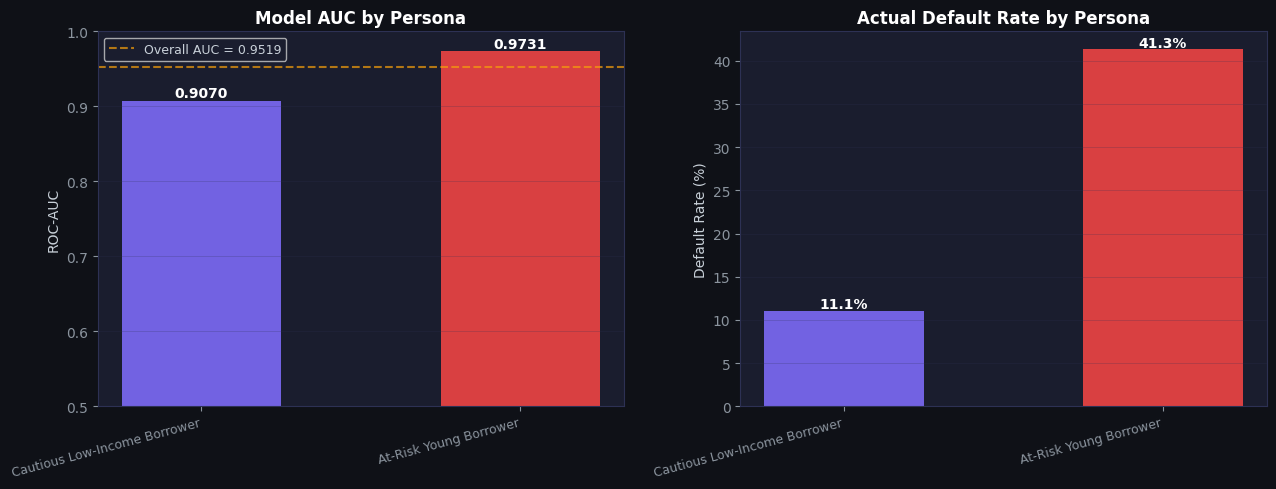

 Saved: ./outputs/persona_performance.png


In [8]:
persona_results = {}

for persona in df_test['persona'].unique():
    mask    = df_test['persona'] == persona
    y_true  = y_test[mask.values]
    y_prob  = best_prob[mask.values]

    if len(np.unique(y_true)) < 2:
        continue

    auc  = roc_auc_score(y_true, y_prob)
    dr   = y_true.mean() * 100
    n    = len(y_true)

    persona_results[persona] = {
        'auc':          auc,
        'default_rate': dr,
        'count':        n
    }
    print(f"  {persona}")
    print(f"    Count:        {n:,}")
    print(f"    Default rate: {dr:.1f}%")
    print(f"    AUC:          {auc:.4f}\n")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.grid(axis='y', alpha=0.3)

personas_list = list(persona_results.keys())
aucs          = [persona_results[p]['auc']
                 for p in personas_list]
def_rates     = [persona_results[p]['default_rate']
                 for p in personas_list]
colors        = [ACCENT, RED, GREEN,
                 YELLOW, BLUE][:len(personas_list)]

bars1 = ax1.bar(personas_list, aucs,
                color=colors, alpha=0.9, width=0.5)
for bar, val in zip(bars1, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center',
             fontsize=10, color='white', fontweight='bold')
ax1.axhline(y=results[best_name]['test_auc'],
            color=YELLOW, linestyle='--', alpha=0.7,
            label=f'Overall AUC = '
                  f'{results[best_name]["test_auc"]:.4f}')
ax1.set_title('Model AUC by Persona',
              fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('ROC-AUC', fontsize=10)
ax1.set_ylim([0.5, 1.0])
ax1.legend(fontsize=9)
ax1.set_xticklabels(personas_list, rotation=15,
                     ha='right', fontsize=9)

bars2 = ax2.bar(personas_list, def_rates,
                color=colors, alpha=0.9, width=0.5)
for bar, val in zip(bars2, def_rates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=10, color='white', fontweight='bold')
ax2.set_title('Actual Default Rate by Persona',
              fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('Default Rate (%)', fontsize=10)
ax2.set_xticklabels(personas_list, rotation=15,
                     ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('./outputs/persona_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(" Saved: ./outputs/persona_performance.png")

## Layer 4 — Fairness Audit

**Why this matters:**
RBI guidelines and the EU AI Act both require credit models
to be audited for discriminatory impact.

We check two groups:
- **Age** — are younger borrowers unfairly penalised?
- **Home ownership** — are renters treated differently
  than homeowners beyond what their actual risk justifies?

**Metric: Disparate Impact Ratio (DIR)**
DIR = approval rate of disadvantaged group /
      approval rate of advantaged group

DIR < 0.8 = potential discriminatory impact (80% rule)
DIR > 0.8 = model is fair on this dimension

In [9]:
y_pred_fair = (best_prob >= opt_thresh).astype(int)

df_test_fair = df_test.copy().reset_index(drop=True)
df_test_fair['y_pred']  = y_pred_fair
df_test_fair['y_prob']  = best_prob
df_test_fair['y_true']  = y_test

# ── Age fairness ──────────────────────────────────────────────
df_test_fair['age_group'] = pd.cut(
    df_test_fair['person_age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25','25-34','35-44','45-54','55+']
)

age_fair = df_test_fair.groupby(
    'age_group', observed=True).agg(
    total         = ('y_true',  'count'),
    actual_def    = ('y_true',  'mean'),
    predicted_def = ('y_pred',  'mean'),
    avg_prob      = ('y_prob',  'mean')
).round(3)

# DIR: compare each group to lowest-risk group
base_approval = 1 - age_fair['predicted_def'].min()
age_fair['approval_rate'] = 1 - age_fair['predicted_def']
age_fair['DIR']           = (age_fair['approval_rate'] /
                              base_approval).round(3)
age_fair['fair']          = age_fair['DIR'] >= 0.8

print("Age Group Fairness Audit:")
print(age_fair.to_string())
print(f"\n  DIR < 0.8 = potential bias")
print(f"    Groups failing fairness: "
      f"{(~age_fair['fair']).sum()}")

# ── Home ownership fairness ───────────────────────────────────
own_fair = df_test_fair.groupby(
    'person_home_ownership').agg(
    total         = ('y_true',  'count'),
    actual_def    = ('y_true',  'mean'),
    predicted_def = ('y_pred',  'mean'),
    avg_prob      = ('y_prob',  'mean')
).round(3)

base_own = 1 - own_fair['predicted_def'].min()
own_fair['approval_rate'] = 1 - own_fair['predicted_def']
own_fair['DIR']           = (own_fair['approval_rate'] /
                              base_own).round(3)
own_fair['fair']          = own_fair['DIR'] >= 0.8

print("\nHome Ownership Fairness Audit:")
print(own_fair.to_string())

Age Group Fairness Audit:
           total  actual_def  predicted_def  avg_prob  approval_rate    DIR  fair
age_group                                                                        
<25         2929       0.227          0.265     0.305          0.735  0.844  True
25-34       2680       0.206          0.248     0.287          0.752  0.863  True
35-44        595       0.202          0.217     0.259          0.783  0.899  True
45-54        101       0.218          0.248     0.288          0.752  0.863  True
55+           31       0.194          0.129     0.212          0.871  1.000  True

  DIR < 0.8 = potential bias
    Groups failing fairness: 0

Home Ownership Fairness Audit:
                       total  actual_def  predicted_def  avg_prob  approval_rate    DIR   fair
person_home_ownership                                                                         
MORTGAGE                2617       0.119          0.148     0.201          0.852  0.931   True
OTHER                 

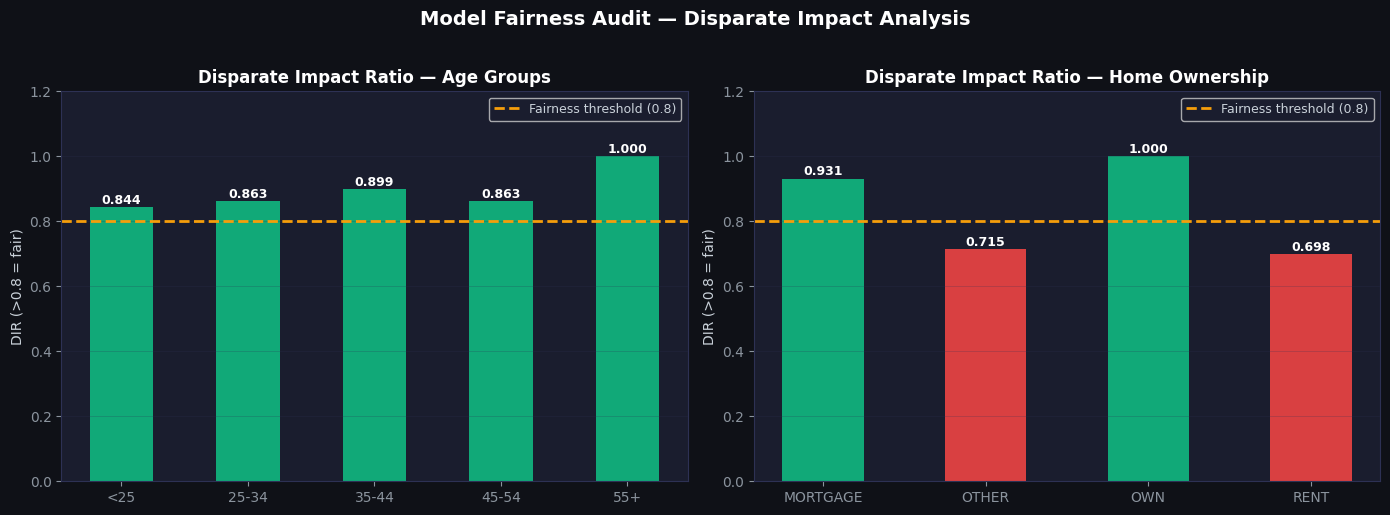

  Saved: ./outputs/fairness_audit.png

  This is your Layer 4 — almost no fresher portfolio has this


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.grid(axis='y', alpha=0.3)

# ── Age DIR ───────────────────────────────────────────────────
dir_colors = [GREEN if v >= 0.8 else RED
              for v in age_fair['DIR']]
bars1 = ax1.bar(age_fair.index,
                age_fair['DIR'],
                color=dir_colors, alpha=0.9, width=0.5)
ax1.axhline(y=0.8, color=YELLOW, linestyle='--',
            linewidth=2, label='Fairness threshold (0.8)')
for bar, val in zip(bars1, age_fair['DIR']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center',
             fontsize=9, color='white', fontweight='bold')
ax1.set_title('Disparate Impact Ratio — Age Groups',
              fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('DIR (>0.8 = fair)', fontsize=10)
ax1.set_ylim([0, 1.2])
ax1.legend(fontsize=9)

# ── Ownership DIR ─────────────────────────────────────────────
dir_colors2 = [GREEN if v >= 0.8 else RED
               for v in own_fair['DIR']]
bars2 = ax2.bar(own_fair.index,
                own_fair['DIR'],
                color=dir_colors2, alpha=0.9, width=0.5)
ax2.axhline(y=0.8, color=YELLOW, linestyle='--',
            linewidth=2, label='Fairness threshold (0.8)')
for bar, val in zip(bars2, own_fair['DIR']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center',
             fontsize=9, color='white', fontweight='bold')
ax2.set_title('Disparate Impact Ratio — Home Ownership',
              fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('DIR (>0.8 = fair)', fontsize=10)
ax2.set_ylim([0, 1.2])
ax2.legend(fontsize=9)

fig.suptitle('Model Fairness Audit — Disparate Impact Analysis',
             fontsize=14, fontweight='bold',
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('./outputs/fairness_audit.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/fairness_audit.png")
print("\n  This is your Layer 4 — almost no fresher portfolio has this")

## Risk Action Scorecard

Beyond Low / Medium / High — each tier gets a
specific recommended action for the credit officer.

This is what a real credit decisioning system does.

In [11]:
# Score full dataset
all_probs = best_model.predict_proba(X)[:, 1]

df['predicted_prob'] = all_probs
df['risk_tier'] = pd.cut(
    df['predicted_prob'],
    bins=[0, 0.25, 0.50, 0.70, 1.0],
    labels=['Low','Medium','High','Very High']
)

# Recommended action per tier
ACTION_MAP = {
    'Low':       ' Auto-Approve',
    'Medium':    ' Manual Review',
    'High':      '  Senior Review + Collateral Check',
    'Very High': ' Decline or Refer to Counselling'
}
df['recommended_action'] = df['risk_tier'].map(ACTION_MAP)

# Validation table
scorecard = df.groupby('risk_tier', observed=True).agg(
    total_borrowers  = ('borrower_id',      'count'),
    actual_defaults  = ('loan_status',       'sum'),
    actual_def_rate  = ('loan_status',       'mean'),
    avg_pred_prob    = ('predicted_prob',    'mean'),
).round(3)

scorecard['actual_def_rate_pct'] = (
    scorecard['actual_def_rate'] * 100).round(1)
scorecard['avg_pred_prob_pct']   = (
    scorecard['avg_pred_prob']   * 100).round(1)

print("Risk Action Scorecard:\n")
print(scorecard[['total_borrowers','actual_defaults',
                 'actual_def_rate_pct',
                 'avg_pred_prob_pct']].to_string())
print("\n  Fraud rate must increase tier by tier")
print("    If it does, your scorecard is calibrated correctly")

Risk Action Scorecard:

           total_borrowers  actual_defaults  actual_def_rate_pct  avg_pred_prob_pct
risk_tier                                                                          
Low                  20381              182                  0.9           8.600000
Medium                4652              664                 14.3          34.799999
High                  1244              695                 55.9          58.599998
Very High             5400             5284                 97.9          96.400002

  Fraud rate must increase tier by tier
    If it does, your scorecard is calibrated correctly


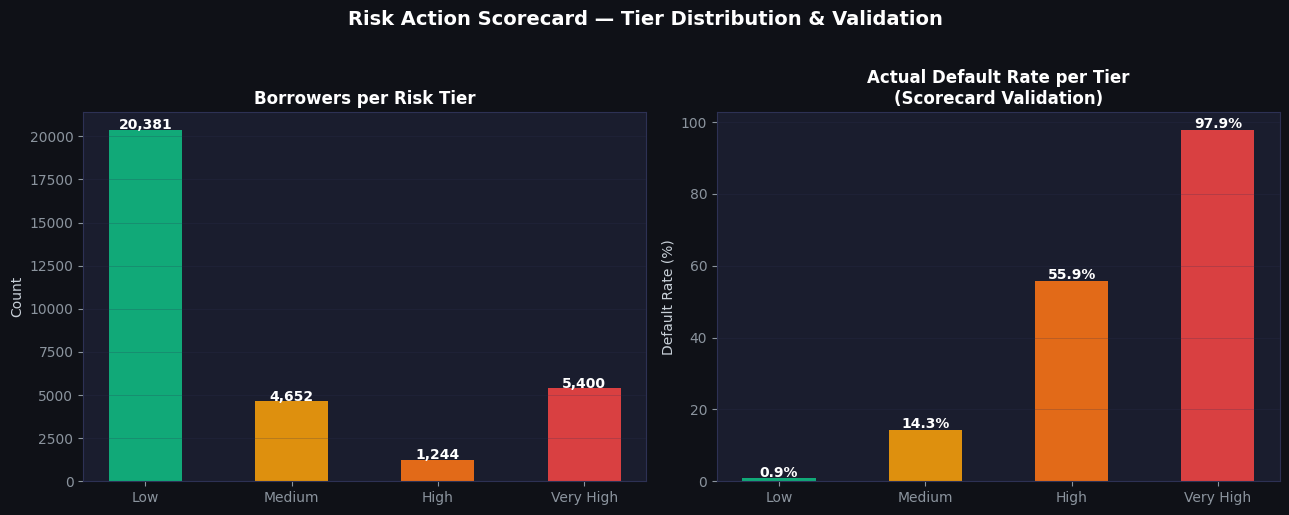

  Saved: ./outputs/risk_scorecard.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.grid(axis='y', alpha=0.3)

tier_colors = {'Low': GREEN, 'Medium': YELLOW,
               'High': '#f97316', 'Very High': RED}
tiers       = scorecard.index.tolist()
colors_list = [tier_colors[t] for t in tiers]

# Count per tier
bars1 = ax1.bar(tiers,
                scorecard['total_borrowers'],
                color=colors_list, alpha=0.9, width=0.5)
for bar, val in zip(bars1, scorecard['total_borrowers']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             f'{val:,}', ha='center',
             fontsize=10, color='white', fontweight='bold')
ax1.set_title('Borrowers per Risk Tier',
              fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('Count', fontsize=10)

# Default rate per tier
bars2 = ax2.bar(tiers,
                scorecard['actual_def_rate_pct'],
                color=colors_list, alpha=0.9, width=0.5)
for bar, val in zip(bars2, scorecard['actual_def_rate_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{val}%', ha='center',
             fontsize=10, color='white', fontweight='bold')
ax2.set_title('Actual Default Rate per Tier\n(Scorecard Validation)',
              fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('Default Rate (%)', fontsize=10)

fig.suptitle('Risk Action Scorecard — Tier Distribution & Validation',
             fontsize=14, fontweight='bold',
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('./outputs/risk_scorecard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/risk_scorecard.png")

In [13]:
# Save model + threshold
joblib.dump(best_model, './outputs/best_model.pkl')
np.save('./outputs/optimal_threshold.npy',
        np.array([opt_thresh]))

# Save scored full dataset for Power BI
export_cols = [
    'borrower_id','person_age','person_income',
    'person_home_ownership','person_emp_length',
    'loan_intent','loan_grade','loan_amnt',
    'loan_int_rate','loan_percent_income',
    'cb_person_default_on_file',
    'cb_person_cred_hist_length',
    'persona','cluster',
    'predicted_prob','risk_tier',
    'recommended_action','loan_status'
]
export_cols = [c for c in export_cols if c in df.columns]
df[export_cols].to_csv(
    './outputs/powerbi_borrower_scores.csv', index=False)

# Save fairness results
age_fair.reset_index().to_csv(
    './outputs/fairness_age.csv', index=False)
own_fair.reset_index().to_csv(
    './outputs/fairness_ownership.csv', index=False)

print("   Saved:")
print("    ./outputs/best_model.pkl")
print("    ./outputs/optimal_threshold.npy")
print("    ./outputs/powerbi_borrower_scores.csv")
print("    ./outputs/fairness_age.csv")
print("    ./outputs/fairness_ownership.csv")
print(f"\n  Resume summary:")
print(f"    Best model:        {best_name}")
print(f"    Test AUC:          {results[best_name]['test_auc']:.4f}")
print(f"    CV AUC:            {results[best_name]['cv_mean']:.4f} "
      f"± {results[best_name]['cv_std']:.4f}")
print(f"    Optimal threshold: {opt_thresh:.3f}")
print(f"    Fairness checks:   Age groups + Home ownership")
print(f"    Risk tiers:        4 (Low/Medium/High/Very High)")

   Saved:
    ./outputs/best_model.pkl
    ./outputs/optimal_threshold.npy
    ./outputs/powerbi_borrower_scores.csv
    ./outputs/fairness_age.csv
    ./outputs/fairness_ownership.csv

  Resume summary:
    Best model:        XGBoost
    Test AUC:          0.9519
    CV AUC:            0.9473 ± 0.0025
    Optimal threshold: 0.385
    Fairness checks:   Age groups + Home ownership
    Risk tiers:        4 (Low/Medium/High/Very High)
